In [1]:
%load_ext autoreload
%autoreload 2


import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import os, sys

import plotly.graph_objects as go

root_dir = os.path.abspath('../..')

if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.utils import img_polar2cart

import pandas as pd

In [28]:

# read csv 
csv_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/selfsupervised/val/seq_15/sequence.csv'

df = pd.read_csv(csv_pth)

# data:
df.head()        
df.info()        
df.columns       
df.shape     

series_x = df['pos_x']
series_y = df['pos_y']
series_z = df['pos_z']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   step_idx      1000 non-null   int64  
 1   timestamp     1000 non-null   float64
 2   pos_x         1000 non-null   float64
 3   pos_y         1000 non-null   float64
 4   pos_z         1000 non-null   float64
 5   quat_x        1000 non-null   float64
 6   quat_y        1000 non-null   float64
 7   quat_z        1000 non-null   float64
 8   quat_w        1000 non-null   float64
 9   dvl_vel_x     1000 non-null   float64
 10  dvl_vel_y     1000 non-null   float64
 11  dvl_vel_z     1000 non-null   float64
 12  dvl_alt       1000 non-null   float64
 13  imu_orient_x  1000 non-null   float64
 14  imu_orient_y  1000 non-null   float64
 15  imu_orient_z  1000 non-null   float64
 16  imu_orient_w  1000 non-null   float64
 17  imu_gyro_x    1000 non-null   float64
 18  imu_gyro_y    1000 non-null  

In [43]:
# Display only trajectory
start = 280
end = 920

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=series_x[start:end], 
    y=series_y[start:end], 
    z=series_z[start:end],
    mode='lines',
    name='trajektoria',
    line=dict(color='blue', width=4)
))

fig.update_layout(
    # title="Trajektoria",
    scene=dict(
        xaxis_title=' X (m)',
        yaxis_title=' Y (m)',
        zaxis_title=' Z (m)',
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.5)
    ),
    width=900,
    height=700
)

fig.show()

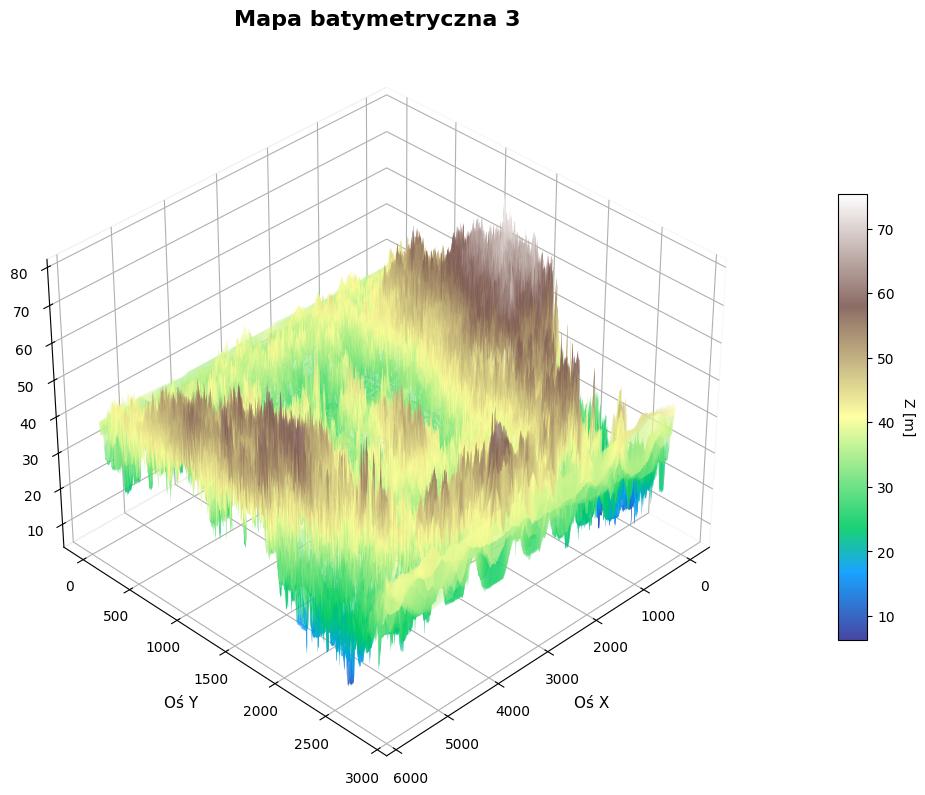

In [19]:
# Display preapared scenarios for simulating data 


# seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/ocean2.png'
              
# seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/fiords.png'
              
seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/seabed_moon.png'
              
title = 'Mapa batymetryczna 3'

# 1. Wczytanie obrazu w odcieniach szarości
Z = cv2.imread(seabed_pth, 0)
if Z is None:
    raise FileNotFoundError(f"Nie udało się wczytać pliku: {seabed_pth}")

h, w = Z.shape 

# 2. Przygotowanie siatki współrzędnych
x = np.linspace(0, w, w)
y = np.linspace(0, h, h)
X, Y = np.meshgrid(x, y)
Zf = Z.astype(np.float64)
Zf[Zf < 10] = np.nan

# 3. Tworzenie pojedynczego wykresu
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

surf = ax.plot_surface(
    X, Y, Zf*0.5, 
    cmap='terrain', 
    linewidth=0,        # Brak czarnej siatki
    antialiased=True,   # Wygładzanie krawędzi
    rstride=10,          # Gęstość próbkowania wierszy (zwiększ np. do 4 dla płynniejszego obracania)
    cstride=10,          # Gęstość próbkowania kolumn
    alpha=0.9
)

# 4. Stylizacja osi i tytułu
ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Oś X', fontsize=11, labelpad=10)
ax.set_ylabel('Oś Y', fontsize=11, labelpad=10)
ax.set_zlabel('Wysokość Z', fontsize=11, labelpad=10)

# Ustawienie kąta obserwacji
ax.view_init(elev=35, azim=45)

# Ukrycie szarych ścian w tle
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# 5. Pasek skali (colorbar)
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Z [m]', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()
